# Getting Started with Time Series Analysis

Data is dowloaded from - [Kaggle - Store Sales Time Series Forecasting](https://www.kaggle.com/competitions/store-sales-time-series-forecasting/data)

In [1]:
import warnings
from statsmodels.tsa.base.tsa_model import ValueWarning

# Filter out specific warnings from statsmodels
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=ValueWarning)
warnings.filterwarnings("ignore", category=UserWarning)

In [2]:
import pandas as pd
import numpy as np
from google.colab import drive
import matplotlib.pyplot as plt

# Mount Google Drive
drive.mount('/content/drive')

# Define the path to the CSV file in Google Drive
file_path = '/content/drive/MyDrive/Data Science Lecture Notes/data/store_sales_time_series/train.csv'

sales_df = pd.read_csv(file_path)
agg_sales_df = sales_df['sales'].groupby(sales_df['date']).sum()
agg_sales_df = pd.DataFrame(agg_sales_df)
agg_sales_df['time_step'] = range(len(agg_sales_df))
agg_sales_df.dropna(inplace=True)

Mounted at /content/drive


# Simple Data Visualization

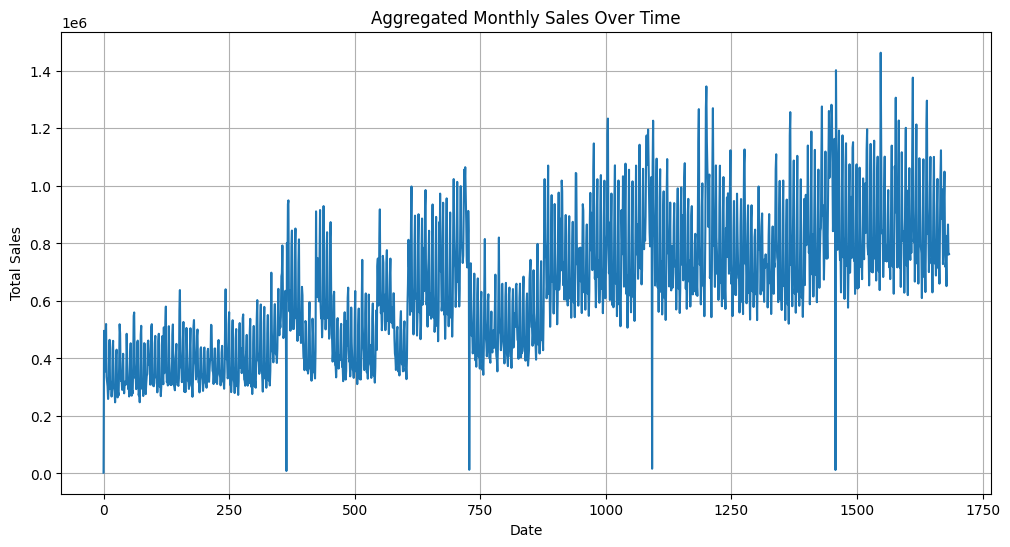

In [3]:
# Plot the aggregated sales data
plt.figure(figsize=(12, 6))
plt.plot(agg_sales_df.time_step, agg_sales_df.sales)
plt.title('Aggregated Monthly Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.grid(True)
plt.show()

In [4]:
len(agg_sales_df)

1684

In [30]:
agg_sales_df.head()

,sales,time_step
date,,
2013-01-01,2511.618999,0
2013-01-02,496092.417944,1
2013-01-03,361461.231124,2
2013-01-04,354459.677093,3
2013-01-05,477350.121229,4


# Check and fix Stationarity

In [5]:
from statsmodels.tsa.stattools import adfuller

# Perform the ADF test on the 'sales' column
adf_test_result = adfuller(agg_sales_df['sales'])

# Extract and print the ADF statistic and p-value
print(f'ADF Statistic: {adf_test_result[0]}')
print(f'P-value: {adf_test_result[1]}')

# Interpret the results
alpha = 0.05
if adf_test_result[1] < alpha:
    print('The time series is likely stationary (reject H0)')
else:
    print('The time series is likely non-stationary (fail to reject H0)')

ADF Statistic: -2.6161957486048566
P-value: 0.08969592175787472
The time series is likely non-stationary (fail to reject H0)


## Apply differencing
Apply differencing (e.g., first-order differencing) to the non-stationary data.


In [6]:
# Apply first-order differencing
agg_sales_df_differenced = agg_sales_df['sales'].diff().dropna()

# Display the first few rows of the differenced data
display(agg_sales_df_differenced.head())

,sales
date,
2013-01-02,493580.798945
2013-01-03,-134631.186820
2013-01-04,-7001.554031
2013-01-05,122890.444136
2013-01-06,42345.279859


## Check for stationarity after differencing

Apply the ADF test again to the differenced data to check if that it has become stationary.


In [7]:
from statsmodels.tsa.stattools import adfuller

# Apply the adfuller() function to the differenced data
adf_test_result_differenced = adfuller(agg_sales_df_differenced)

# Print the ADF statistic and the p-value from the test results
print(f'ADF Statistic (Differenced Data): {adf_test_result_differenced[0]}')
print(f'P-value (Differenced Data): {adf_test_result_differenced[1]}')

# Define the significance level (already defined as alpha = 0.05)
alpha = 0.05

# Compare the p-value to the significance level and print whether the differenced time series is likely stationary or non-stationary
if adf_test_result_differenced[1] < alpha:
    print('The differenced time series is likely stationary (reject H0)')
else:
    print('The differenced time series is likely non-stationary (fail to reject H0)')

ADF Statistic (Differenced Data): -11.49759976266105
P-value (Differenced Data): 4.5737684173425986e-21
The differenced time series is likely stationary (reject H0)


## Visualize results

Plot the original non-stationary data and the differenced stationary data to visually demonstrate the effect of differencing.


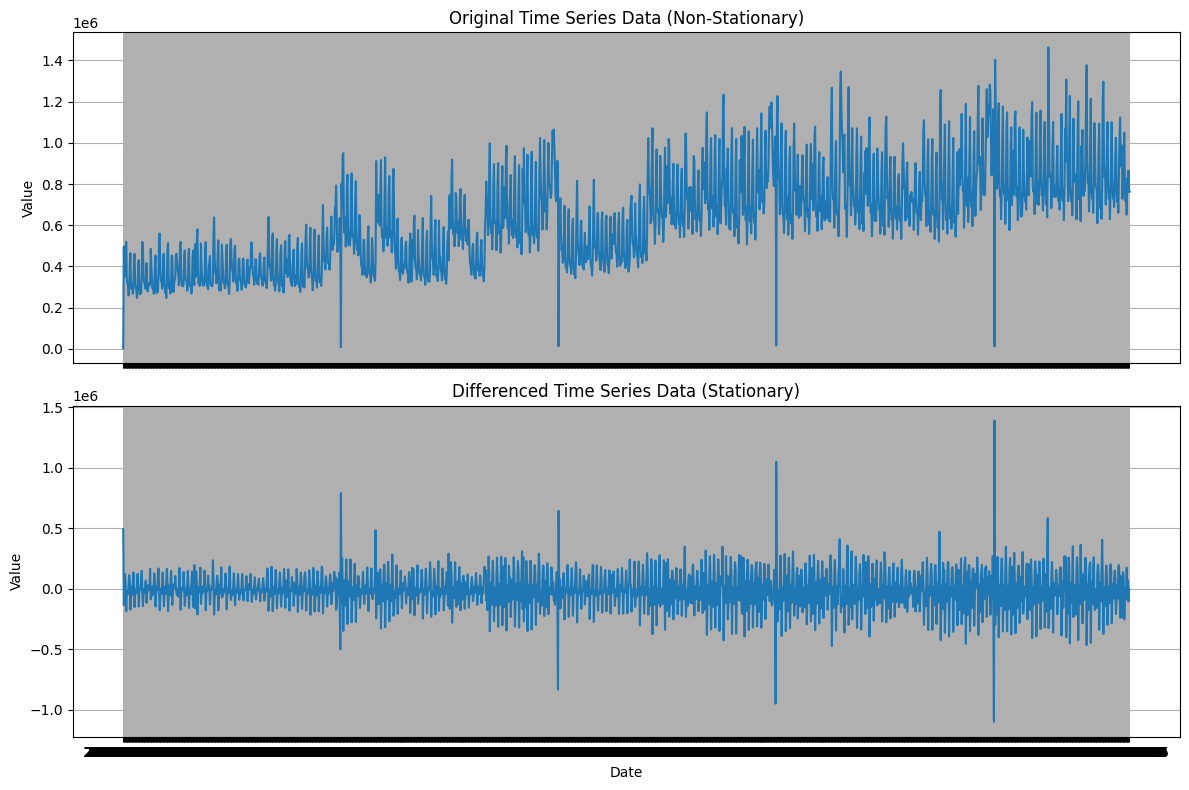

In [8]:
import matplotlib.pyplot as plt

# Create a figure with two subplots stacked vertically
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Plot the original time series data
axes[0].plot(agg_sales_df['time_step'], agg_sales_df['sales'])
axes[0].set_title('Original Time Series Data (Non-Stationary)')
axes[0].set_ylabel('Value')
axes[0].grid(True)

# Plot the differenced time series data
axes[1].plot(agg_sales_df_differenced)
axes[1].set_title('Differenced Time Series Data (Stationary)')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Value')
axes[1].grid(True)

# Improve layout to prevent overlapping
plt.tight_layout()

# Display the plot
plt.show()

# Model Identification (ACF and PACF Plots)

## Determining p and q using ACF and PACF Plots

After ensuring your time series data is stationary (by differencing if necessary, which determines the 'd' parameter of ARIMA), you can use Autocorrelation Function (ACF) and Partial Autocorrelation Function (PACF) plots to identify the appropriate orders for the Autoregressive (AR) and Moving Average (MA) components of the ARIMA model.

Here's how to interpret the plots:

### Autocorrelation Function (ACF)

The ACF plot shows the correlation between a time series and its lagged values at different lags.

### Partial Autocorrelation Function (PACF)

The PACF plot shows the correlation between a time series and its lagged values, with the influence of the correlations from the intermediate lags removed.


**Important Considerations:**

*   **Significance:** Focus on the spikes that extend beyond the shaded confidence intervals in the plots, as these indicate statistically significant correlations.
*   **Seasonality:** If your data has seasonality, you might need to consider a Seasonal ARIMA (SARIMA) model, and you would look for similar patterns at seasonal lags in the ACF and PACF plots.
*   **Iterative Process:** Model identification is often an iterative process. You might start with initial guesses for p and q based on the plots, fit the model, and then evaluate the residuals to see if they are white noise. If not, you might need to adjust the model orders.
*   **Auto_arima:** Libraries like `pmdarima` provide `auto_arima` functions that can automatically search for the best ARIMA parameters based on information criteria, which can be helpful, especially for beginners or complex time series.

By carefully examining the patterns in the ACF and PACF plots of your stationary time series, you can make informed decisions about the appropriate orders for the AR(p) and MA(q) components of your ARIMA model.

## Rules of thumb for identifying p and q
**Rules of thumb for identifying p (AR terms) and q (MA terms)** using **ACF and PACF** charts. These rules are widely used for building **ARIMA models** (or SARIMA with seasonality) and work best when the series has been made **stationary** (via differencing, if needed).

---

## ✅ Quick Definitions:

* **p**: Number of **autoregressive (AR)** terms — depends on **PACF**
* **q**: Number of **moving average (MA)** terms — depends on **ACF**

---

## 📘 Rules of Thumb for Identifying `p` and `q`

| Chart                                       | Cutoff Pattern                            | Interpretation                 | Choose...        |
| ------------------------------------------- | ----------------------------------------- | ------------------------------ | ---------------- |
| **PACF**                                    | Sharp cutoff after lag `p` and then drops | AR process                     | `p = cutoff lag` |
| **ACF**                                     | Sharp cutoff after lag `q` and then drops | MA process                     | `q = cutoff lag` |
| **Both taper off**                          | No sharp cutoff, just slow decay          | ARMA process                   | Try both p and q |
| **Both cut off**                            | Complex model                             | May need ARMA or SARIMA        |                  |
| **Seasonal spikes** (e.g., at lag 7, 14...) | Seasonality present                       | Use SARIMA with seasonal terms |                  |

---

## 🔍 How to Identify Cutoff (with 95% Confidence Bands):

* A **"cutoff"** means the correlation values drop to **within the confidence bands** (i.e., become statistically insignificant) and stay that way.
* A **"tapering"** means the values decay **gradually** and don't sharply die off.

---

### 🔷 Example Patterns

#### 1. **AR(p)** process:

* **PACF**: Sharp cutoff after lag `p`
* **ACF**: Tapers off

✅ Choose: `p = cutoff`, `q = 0`

#### 2. **MA(q)** process:

* **ACF**: Sharp cutoff after lag `q`
* **PACF**: Tapers off

✅ Choose: `p = 0`, `q = cutoff`

#### 3. **ARMA(p,q)** process:

* **Both ACF and PACF taper**

✅ Choose: `p > 0`, `q > 0` — try small values for both

---

## 📊 Visual Cheatsheet

| ACF             | PACF            | Likely Model             |
| --------------- | --------------- | ------------------------ |
| Tapering        | Sharp cutoff    | AR(p)                    |
| Sharp cutoff    | Tapering        | MA(q)                    |
| Tapering        | Tapering        | ARMA(p, q)               |
| Seasonal spikes | Seasonal spikes | SARIMA with seasonal P/Q |

---

## 🧪 Pro Tip: Use `auto_arima` or `AIC/BIC` to confirm

Once you hypothesize `p` and `q`:

* Run the models with different (p, q) combinations
* Compare using **AIC**, **BIC**, and **residual diagnostics**

---

## 🎓 Summary

| Step | Action                                                |
| ---- | ----------------------------------------------------- |
| 1    | Check stationarity (ADF test, differencing if needed) |
| 2    | Plot ACF and PACF                                     |
| 3    | Use rules above to estimate `p` and `q`               |
| 4    | Try ARIMA(p,d,q) or SARIMA(p,d,q)(P,D,Q,s)            |
| 5    | Validate with AIC, BIC, residual plots                |

---



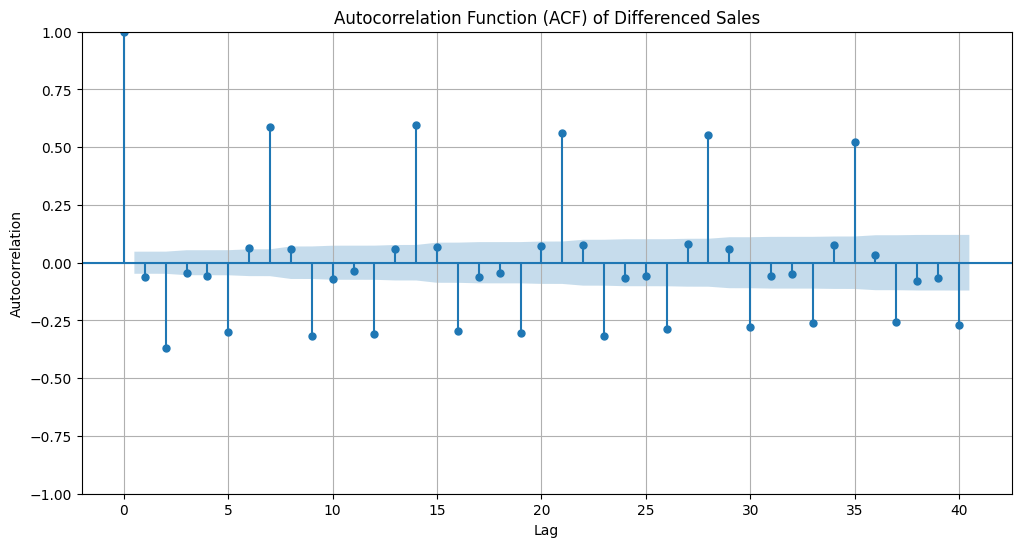

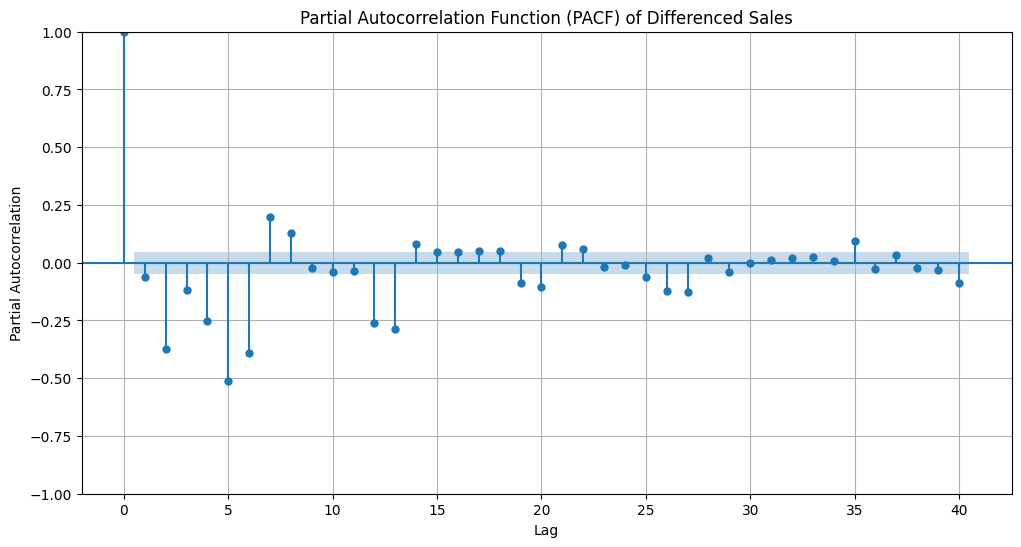

In [9]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

# Plot ACF of the differenced data
plt.figure(figsize=(12, 6))
plot_acf(agg_sales_df_differenced, lags=40, ax=plt.gca())
plt.title('Autocorrelation Function (ACF) of Differenced Sales')
plt.xlabel('Lag')
plt.ylabel('Autocorrelation')
plt.grid(True)
plt.show()

# Plot PACF of the differenced data
plt.figure(figsize=(12, 6))
plot_pacf(agg_sales_df_differenced, lags=40, ax=plt.gca())
plt.title('Partial Autocorrelation Function (PACF) of Differenced Sales')
plt.xlabel('Lag')
plt.ylabel('Partial Autocorrelation')
plt.grid(True)
plt.show()

In [10]:
from statsmodels.tsa.stattools import pacf

# Calculate PACF values for the differenced data
pacf_values = pacf(agg_sales_df_differenced)

# Print the PACF values
print("PACF values of Differenced Sales:")
print(pacf_values)

PACF values of Differenced Sales:
[ 1.         -0.06257257 -0.37530442 -0.11741224 -0.25298798 -0.51320214
 -0.39438336  0.19697149  0.12824762 -0.02126716 -0.03942746 -0.03669456
 -0.26531534 -0.29630767  0.07992353  0.0471241   0.04625786  0.05522415
  0.05312168 -0.09282852 -0.11319638  0.07572764  0.06096392 -0.01613864
 -0.00937353 -0.06078977 -0.12793817 -0.13578282  0.0205562  -0.03688738
 -0.00206416  0.01585546  0.0222261 ]


In [11]:
from statsmodels.tsa.stattools import acf

# Calculate ACF values for the differenced data
acf_values = acf(agg_sales_df_differenced, nlags=40)

# Print the ACF values
print("ACF values of Differenced Sales:")
print(acf_values)

ACF values of Differenced Sales:
[ 1.         -0.06253539 -0.36948006 -0.04508118 -0.05758746 -0.30203746
  0.06437382  0.5861762   0.06032752 -0.31920686 -0.06938377 -0.03715467
 -0.3075222   0.05981552  0.59798845  0.06835227 -0.29409173 -0.06216148
 -0.04617346 -0.30219005  0.07187951  0.55978287  0.07612465 -0.31507234
 -0.06713116 -0.05952163 -0.28692807  0.08168421  0.55186428  0.06116141
 -0.27620575 -0.05703927 -0.05076369 -0.2600803   0.07757726  0.52313441
  0.03441971 -0.25645691 -0.07721143 -0.06736442 -0.27162848]


**Standard rule** to determine statistical significance for ACF and PACF values.

---

## Significance Threshold for ACF/PACF

The 95% confidence threshold is:

$$
\boxed{|\text{ACF or PACF value}| > \frac{1.96}{\sqrt{N}}}
$$

Where:

* $N$ = number of observations in your **original time series**
* $1.96$ corresponds to the 97.5 percentile of the normal distribution (two-tailed, so 95% total)

---

### 🧠 Why this works:

This comes from the assumption that under the null hypothesis (no autocorrelation), the sample autocorrelations are approximately normally distributed with mean 0 and standard deviation $\frac{1}{\sqrt{N}}$.

---

## 🧮 Example Thresholds

| N (data points) | Threshold = 1.96 / √N |
| --------------- | --------------------- |
| 100             | ≈ 0.196               |
| 150             | ≈ 0.160               |
| 200             | ≈ 0.138               |
| 300             | ≈ 0.113               |
| 500             | ≈ 0.088               |

---

### ✅ So when reading ACF/PACF plots:

* **Draw horizontal lines at ±(1.96 / √N)** as confidence bands.
* Any spike **outside those bands** = statistically significant autocorrelation at that lag.
* This applies to **both**:

  * **ACF** (total correlation at each lag)
  * **PACF** (correlation with adjustment for intermediate lags)

---

## ❗Important Notes

1. This threshold applies **after differencing** (i.e., use N from the differenced series).
2. You can also use `statsmodels.graphics.tsaplots.plot_acf()` or `plot_pacf()`, which draw these bands automatically.
---

In [12]:
Significance_level = 1.96 / np.sqrt(len(agg_sales_df_differenced))
print(Significance_level)

0.04777646504297253


In [13]:
significant_pacf_lags = np.where(np.abs(pacf_values) >= Significance_level)[0]
print("Significant PACF lags:", significant_pacf_lags)

Significant PACF lags: [ 0  1  2  3  4  5  6  7  8 12 13 14 17 18 19 20 21 22 25 26 27]


In [14]:
significant_acf_lags = np.where(np.abs(acf_values) >= Significance_level)[0]
print("Significant ACF lags:", significant_acf_lags)

Significant ACF lags: [ 0  1  2  4  5  6  7  8  9 10 12 13 14 15 16 17 19 20 21 22 23 24 25 26
 27 28 29 30 31 32 33 34 35 37 38 39 40]


Now that you've listed the **significant PACF and ACF lags** (based on the accurate threshold of ±0.0478 for 1684 samples), we can do a **true interpretation** of the series and guide you in selecting the most appropriate model.

Let’s go step-by-step to understand what these results mean.

---

## 🔍 Summary of Significant Lags

### ✅ Significant PACF lags:

```python
[ 0  1  2  3  4  5  6  7  8 12 13 14 17 18 19 20 21 22 25 26 27 ]
```

→ These suggest **strong partial correlations** up to lag 8, and then again between lags 12–14 and 17–22.

---

### ✅ Significant ACF lags:

```python
[ 0  1  2  4  5  6  7  8  9 10 12 13 14 15 16 17 19 20 21 22 23 24 25 26
 27 28 29 30 31 32 33 34 35 37 38 39 40 ]
```

→ Strong autocorrelation up to at least **lag 40** — and in **clumps** around 7-lag intervals (e.g., 7, 14, 21, 28, 35) with additional spread in between.

---

## 🧠 2. What Does This Mean?

### 🔷 PACF: Partial autocorrelations are significant through lag 8 → **AR structure likely**.

* Especially strong at lags 1–8
* Additional AR-like structure at lags 12–14 and 17–22 → possibly long-range memory or **seasonality**

### 🔶 ACF: Slowly decaying and periodic → **seasonality is present**

* Strong significance at **lag multiples of 7** → classic weekly cycle
* Spikes persist through lag 40 → this is **not white noise**, not purely MA

---

## ✅ 3. Model Inference from ACF/PACF

Let’s turn these observations into ARIMA or SARIMA model recommendations.

| Component      | Value          | Justification                                      |
| -------------- | -------------- | -------------------------------------------------- |
| `p` (AR order) | 8 (or up to 9) | PACF significant through lag 8                     |
| `d`            | 1              | You’ve differenced the series (already stationary) |
| `q` (MA order) | Likely 0 or 1  | ACF tapers; no sharp cutoff                        |
| `s`            | 7              | ACF shows strong seasonal pattern every 7 lags     |
| `P`            | 1 or 2         | Seasonal spikes at lag 7, 14                       |
| `Q`            | 1 or 2         | Seasonal MA due to ACF spikes at lag 7, 14         |
| `D`            | 0 or 1         | Try both with grid search                          |

---

## 🔧 4. Recommended Model to Try First

### ✅ **SARIMA(8,1,0)(1,0,1,7)**

```python
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(y, order=(8, 1, 0), seasonal_order=(1, 0, 1, 7))
results = model.fit()
```

* Captures the AR structure (lags 1–8)
* Includes weekly seasonal AR/MA components

---

### 🧪 Optional: Use `pmdarima.auto_arima` to Tune

```python
from pmdarima import auto_arima

model = auto_arima(y, start_p=1, start_q=0,
                   max_p=10, max_q=3,
                   start_P=1, start_Q=0,
                   max_P=2, max_Q=2,
                   seasonal=True,
                   m=7,  # seasonality
                   d=1, D=1, trace=True,
                   error_action='ignore',
                   suppress_warnings=True,
                   stepwise=True)
```

---


# Simple ARIMA Model

In [15]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import numpy as np

# The agg_sales_df_differenced is already stationary as per previous steps
# We can directly use this differenced data for modeling with d=0 for the ARIMA order

# Split the data into training and testing sets (maintain time order)
model_train_df = agg_sales_df_differenced # Use the entire Series
train_size = int(len(agg_sales_df_differenced) * 0.8)
train_data, test_data = model_train_df[0:train_size], model_train_df[train_size:]

print(f"Data Size:{len(agg_sales_df_differenced)}")
print(f"Train Data Size: {len(train_data)}")
print(f"Test Data Size: {len(test_data)}")

Data Size:1683
Train Data Size: 1346
Test Data Size: 337




Define the ARIMA model parameters (p, d, q)
Based on the ACF and PACF plots, we can try to determine appropriate p and q values.
For example, if the PACF cuts off at lag p and ACF decays, consider AR(p) (so p, 0, 0)
If the ACF cuts off at lag q and ACF decays, consider MA(q) (so 0, 0, q)
Since we are using differenced data which is stationary, d=0 in the ARIMA model.
Let's start with an initial guess for p and q based on the plots or try auto_arima separately.
For now, let's use a simple example, you might need to tune these parameters.

In [16]:
p, d, q = 8, 0, 1

# Fit the ARIMA model
model = ARIMA(train_data, order=(p, d, q))
model_fit = model.fit()

# Print the model summar
print(model_fit.summary())


                               SARIMAX Results                                
Dep. Variable:                  sales   No. Observations:                 1346
Model:                 ARIMA(8, 0, 1)   Log Likelihood              -17360.879
Date:                Thu, 07 Aug 2025   AIC                          34743.758
Time:                        02:37:57   BIC                          34801.012
Sample:                             0   HQIC                         34765.203
                               - 1346                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        753.9803   1104.208      0.683      0.495   -1410.228    2918.189
ar.L1         -0.6092      0.185     -3.292      0.001      -0.972      -0.247
ar.L2         -0.5720      0.069     -8.314      0.0

In [17]:
# Make predictions on the test set
# The predict method on differenced data will give predictions of the differenced series.
# Ensure the start and end indices are correct for the test set based on the differenced data index.
predictions_diff = model_fit.predict(start=len(train_data), end=len(agg_sales_df_differenced)-1)

In [18]:
predictions_diff

,predicted_mean
1346,-194295.343156
1347,-72451.874928
1348,-3442.270021
1349,-92082.304498
1350,40471.571330
...,...
1678,754.264506
1679,754.173320
1680,753.961354
1681,753.776048


In [19]:
# To get predictions for the original series, we need to inverse the differencing.
# The prediction for the original series at time t is the prediction of the differenced series at t plus the actual value of the original series at t-1.
# We need the last value of the training data of the *original* series to start the inverse differencing process.
# The index of the test_data_original starts one element after the last element of the training data of the original series.
last_train_value_original = agg_sales_df['sales'][train_size - 1]
last_train_value_original


np.float64(915938.559049)

In [20]:
# Create a series for the original series predictions and initialize with the last training value
predictions_original = pd.Series(index=agg_sales_df_differenced[train_size:].index)
predictions_original

,0
date,
2016-09-12,NaN
2016-09-13,NaN
2016-09-14,NaN
2016-09-15,NaN
2016-09-16,NaN
...,...
2017-08-11,NaN
2017-08-12,NaN
2017-08-13,NaN


In [21]:
# The first prediction of the original series is the last known original value plus the first prediction of the differenced series
predictions_original.iloc[0] = last_train_value_original + predictions_diff.iloc[0]
predictions_original

,0
date,
2016-09-12,721643.215893
2016-09-13,NaN
2016-09-14,NaN
2016-09-15,NaN
2016-09-16,NaN
...,...
2017-08-11,NaN
2017-08-12,NaN
2017-08-13,NaN


In [22]:
# Inverse the differencing for the rest of the predictions
for i in range(1, len(predictions_diff)):
    predictions_original.iloc[i] = predictions_original.iloc[i-1] + predictions_diff.iloc[i]

In [23]:
predictions_original

,0
date,
2016-09-12,721643.215893
2016-09-13,649191.340965
2016-09-14,645749.070944
2016-09-15,553666.766446
2016-09-16,594138.337776
...,...
2017-08-11,940478.231654
2017-08-12,941232.404974
2017-08-13,941986.366328


In [24]:
# Evaluate the model using Mean Squared Error and calculate RMSE on the *original* scale
# We need to compare the predictions on the original scale with the actual test data on the original scale.
# The test_data_original starts one element before the predictions_original because of the differencing.
test_data_original = agg_sales_df['sales'][train_size:]

# Align the indices of test_data_original and predictions_original
test_data_original_aligned = test_data_original.iloc[1:]

In [25]:
final_test_predict_df = pd.DataFrame({'Actual': test_data_original_aligned, 'Predicted': predictions_original})
final_test_predict_df

,Actual,Predicted
date,,
2016-09-12,678776.459126,721643.215893
2016-09-13,603427.946974,649191.340965
2016-09-14,624262.071976,645749.070944
2016-09-15,568324.812986,553666.766446
2016-09-16,691912.601466,594138.337776
...,...,...
2017-08-11,826373.722022,940478.231654
2017-08-12,792630.535079,941232.404974
2017-08-13,865639.677471,941986.366328


In [26]:
mse = mean_squared_error(test_data_original_aligned, predictions_original)
rmse = np.sqrt(mse)
print(f'RMSE: {rmse}')
print(f'AIC (Akaike Information Criterion): {model_fit.aic}')
print(f'BIC (Bayesian Information Criterion): {model_fit.bic}')


RMSE: 189922.56478477223
AIC (Akaike Information Criterion): 34743.758381841646
BIC (Bayesian Information Criterion): 34801.0121994539


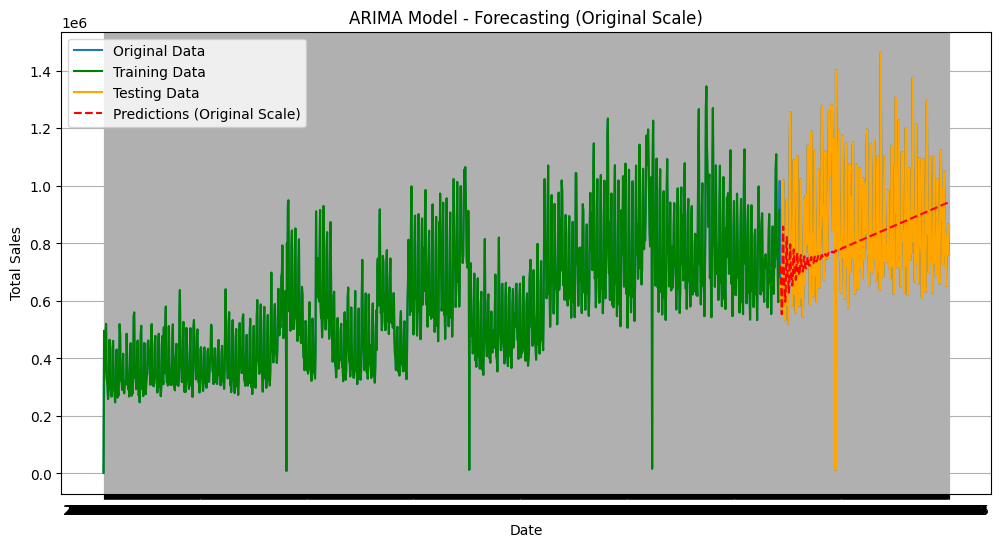

In [27]:
# Plot the original data, training data, testing data, and predictions on the original scale
plt.figure(figsize=(12, 6))
plt.plot(agg_sales_df.index, agg_sales_df['sales'], label='Original Data')
plt.plot(agg_sales_df.index[:train_size], agg_sales_df['sales'][:train_size], label='Training Data', color='green')
plt.plot(test_data_original_aligned.index, test_data_original_aligned, label='Testing Data', color='orange')
plt.plot(predictions_original.index, predictions_original, label='Predictions (Original Scale)', color='red', linestyle='--')
plt.title('ARIMA Model - Forecasting (Original Scale)')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.legend()
plt.grid(True)
plt.show()

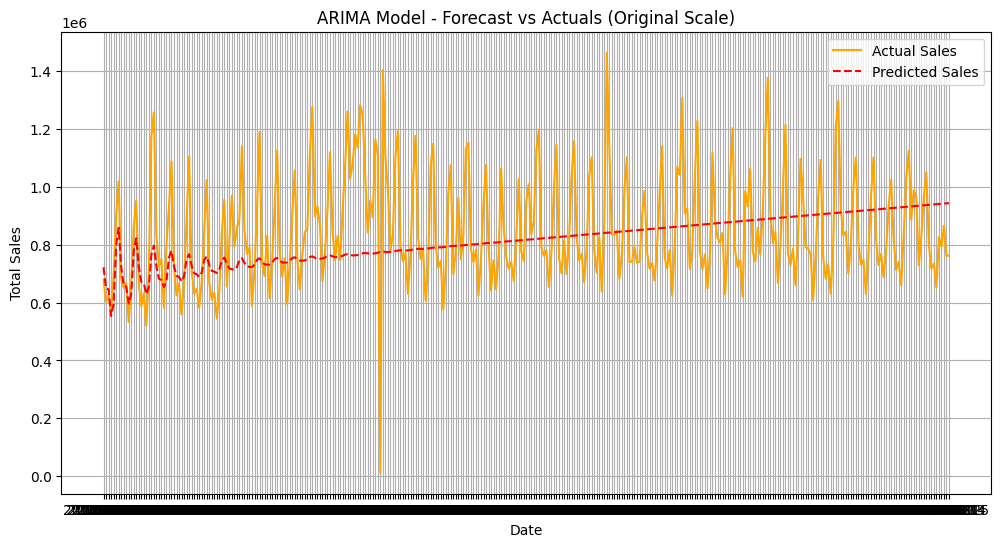

In [28]:
# Plot the actual vs predicted values for the test set
plt.figure(figsize=(12, 6))
plt.plot(test_data_original_aligned.index, test_data_original_aligned, label='Actual Sales', color='orange')
plt.plot(predictions_original.index, predictions_original, label='Predicted Sales', color='red', linestyle='--')
plt.title('ARIMA Model - Forecast vs Actuals (Original Scale)')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.legend()
plt.grid(True)
plt.show()

# ARIMA Experiment for best p, q

In [29]:
stop

NameError: name 'stop' is not defined

In [ ]:
# import itertools
# from statsmodels.tsa.arima.model import ARIMA
# import numpy as np

# p = range(0, 10)
# d = range(0, 3)
# q = range(0, 10)
# pdq = list(itertools.product(p, d, q))

# # Use the differenced data
# ts = agg_sales_df_differenced

# best_aic = np.inf
# best_order = None
# best_model = None

# for order in pdq:
#     try:
#         model = ARIMA(ts, order=order)
#         results = model.fit()
#         print(f'ARIMA{order} - AIC: {results.aic}')
#         if results.aic < best_aic:
#             best_aic = results.aic
#             best_order = order
#             best_model = results
#     except:
#         continue

# print(f'Best ARIMA order: {best_order} with AIC: {best_aic}')

In [ ]:
p, d, q = 9, 0, 8

# Fit the ARIMA model
best_model = ARIMA(train_data, order=(p, d, q))
best_model_fit = best_model.fit()

# Print the model summar
print(best_model_fit.summary())

# Make predictions on the test set
# The predict method on differenced data will give predictions of the differenced series.
# Ensure the start and end indices are correct for the test set based on the differenced data index.
predictions_diff = best_model_fit.predict(start=len(train_data), end=len(agg_sales_df_differenced)-1)

# To get predictions for the original series, we need to inverse the differencing.
# The prediction for the original series at time t is the prediction of the differenced series at t plus the actual value of the original series at t-1.
# We need the last value of the training data of the *original* series to start the inverse differencing process.
# The index of the test_data_original starts one element after the last element of the training data of the original series.
last_train_value_original = agg_sales_df['sales'][train_size - 1]


# Create a series for the original series predictions and initialize with the last training value
predictions_original = pd.Series(index=agg_sales_df_differenced[train_size:].index)

# The first prediction of the original series is the last known original value plus the first prediction of the differenced series
predictions_original.iloc[0] = last_train_value_original + predictions_diff.iloc[0]

# Inverse the differencing for the rest of the predictions
for i in range(1, len(predictions_diff)):
    predictions_original.iloc[i] = predictions_original.iloc[i-1] + predictions_diff.iloc[i]


# Evaluate the model using Mean Squared Error and calculate RMSE on the *original* scale
# We need to compare the predictions on the original scale with the actual test data on the original scale.
# The test_data_original starts one element before the predictions_original because of the differencing.
test_data_original = agg_sales_df['sales'][train_size:]

# Align the indices of test_data_original and predictions_original
test_data_original_aligned = test_data_original.iloc[1:]

mse = mean_squared_error(test_data_original_aligned, predictions_original)
rmse = np.sqrt(mse)
print(f'RMSE: {rmse}')
print(f'AIC (Akaike Information Criterion): {model_fit.aic}')
print(f'BIC (Bayesian Information Criterion): {model_fit.bic}')


In [ ]:
# Plot the original data, training data, testing data, and predictions on the original scale
plt.figure(figsize=(12, 6))
plt.plot(agg_sales_df.index, agg_sales_df['sales'], label='Original Data')
plt.plot(agg_sales_df.index[:train_size], agg_sales_df['sales'][:train_size], label='Training Data', color='green')
plt.plot(test_data_original_aligned.index, test_data_original_aligned, label='Testing Data', color='orange')
plt.plot(predictions_original.index, predictions_original, label='Predictions (Original Scale)', color='red', linestyle='--')
plt.title('ARIMA Model - Forecasting (Original Scale)')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Plot the actual vs predicted values for the test set
plt.figure(figsize=(12, 6))
plt.plot(test_data_original_aligned.index, test_data_original_aligned, label='Actual Sales', color='orange')
plt.plot(predictions_original.index, predictions_original, label='Predicted Sales', color='red', linestyle='--')
plt.title('ARIMA Model - Forecast vs Actuals (Original Scale)')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.legend()
plt.grid(True)
plt.show()

# SARIMAX Model

In [31]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Remove the seasonal AR component (P=0) to avoid overlap with non-seasonal AR(8)
model = SARIMAX(train_data, order=(8, 1, 0), seasonal_order=(0, 0, 1, 7))
results = model.fit()

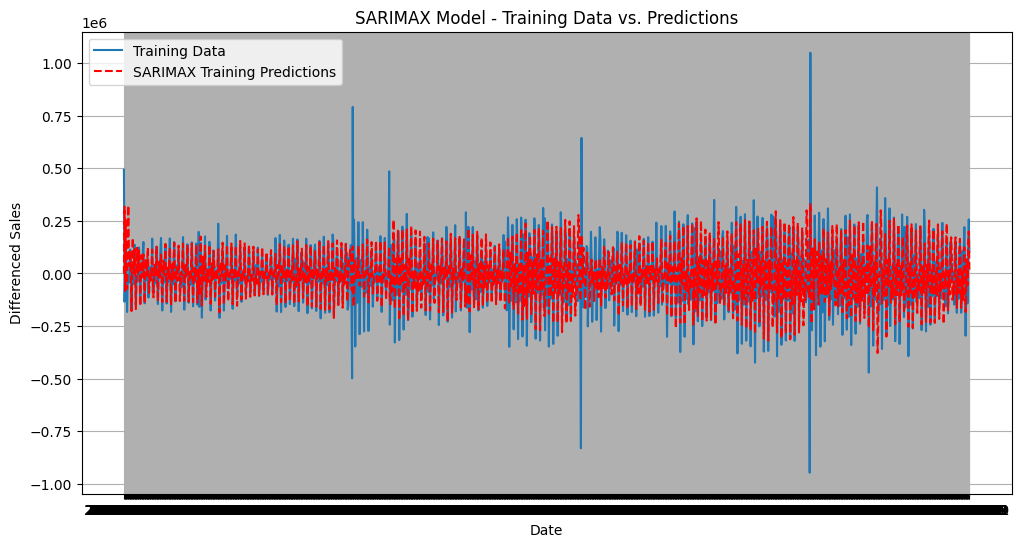

In [32]:
# Plot the training data and predictions
plt.figure(figsize=(12, 6))
plt.plot(train_data.index, train_data, label='Training Data')
plt.plot(train_data.index, results.predict(start=0, end=len(train_data)-1), label='SARIMAX Training Predictions', color='red', linestyle='--')
plt.title('SARIMAX Model - Training Data vs. Predictions')
plt.xlabel('Date')
plt.ylabel('Differenced Sales')
plt.legend()
plt.grid(True)
plt.show()

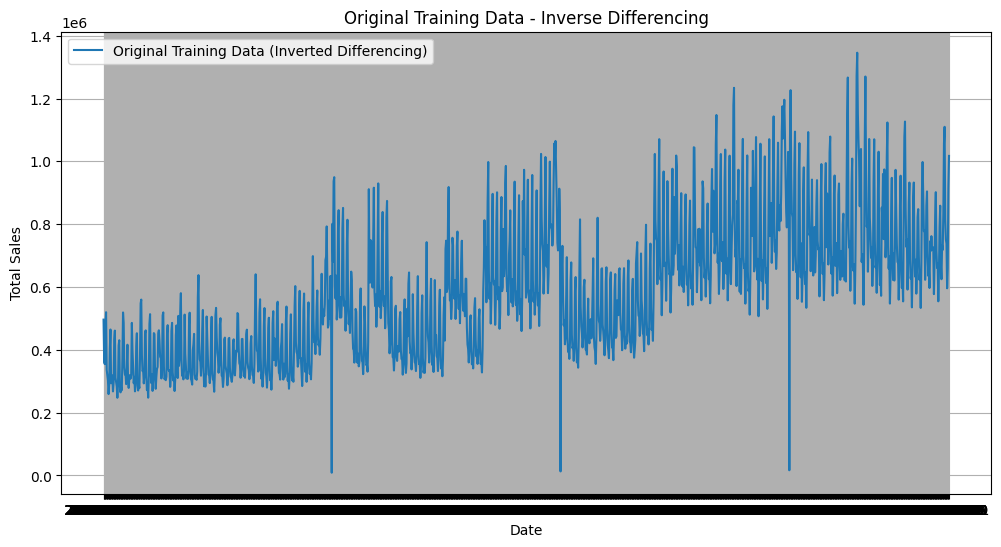

In [33]:
# Inverse the differencing for the training data to visualize on the original scale
# The first value of the original series is needed to start the inverse differencing
first_train_value_original = agg_sales_df['sales'][0]

# Create a series for the original series training data by inverse differencing
train_data_original_inverted = pd.Series(index=train_data.index)
train_data_original_inverted.iloc[0] = first_train_value_original + train_data.iloc[0]

for i in range(1, len(train_data)):
    train_data_original_inverted.iloc[i] = train_data_original_inverted.iloc[i-1] + train_data.iloc[i]

# Plot the original training data obtained by inverse differencing
plt.figure(figsize=(12, 6))
plt.plot(train_data_original_inverted.index, train_data_original_inverted, label='Original Training Data (Inverted Differencing)')

plt.title('Original Training Data - Inverse Differencing')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.legend()
plt.grid(True)
plt.show()

SARIMAX RMSE: 259869.93721133485
SARIMAX AIC: 34603.39176423603
SARIMAX BIC: 34655.433257156394


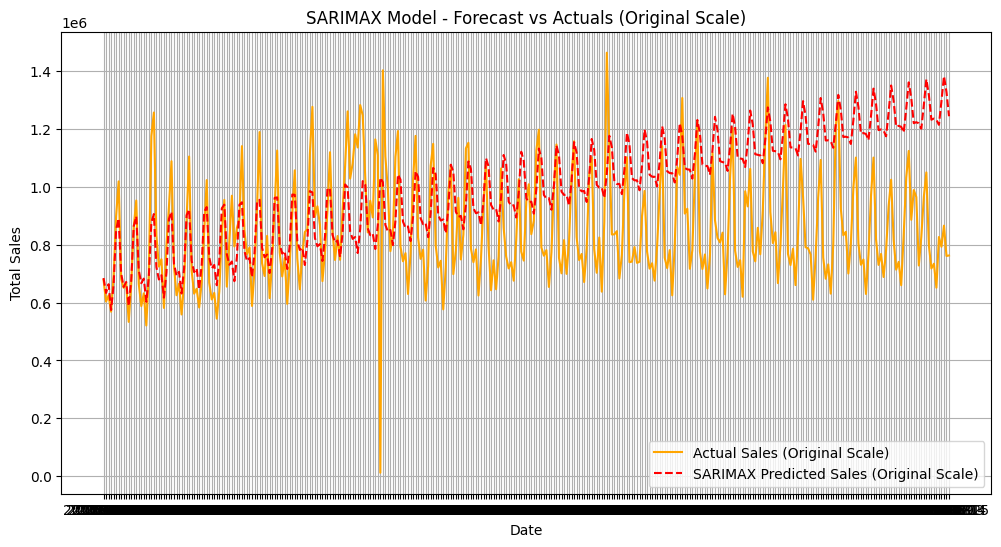

In [34]:
# Make predictions on the test set using the fitted SARIMAX model
# The predict method on differenced data will give predictions of the differenced series.
# Ensure the start and end indices are correct for the test set based on the differenced data index.
predictions_diff_sarimax = results.predict(start=len(train_data), end=len(agg_sales_df_differenced)-1)

# To get predictions for the original series, we need to inverse the differencing.
# The prediction for the original series at time t is the prediction of the differenced series at t plus the actual value of the original series at t-1.
# We need the last value of the training data of the *original* series to start the inverse differencing process.
last_train_value_original = agg_sales_df['sales'][train_size - 1]

# Create a series for the original series predictions and initialize with the last training value
predictions_original_sarimax = pd.Series(index=agg_sales_df_differenced[train_size:].index)

# The first prediction of the original series is the last known original value plus the first prediction of the differenced series
predictions_original_sarimax.iloc[0] = last_train_value_original + predictions_diff_sarimax.iloc[0]

# Inverse the differencing for the rest of the predictions
for i in range(1, len(predictions_diff_sarimax)):
    predictions_original_sarimax.iloc[i] = predictions_original_sarimax.iloc[i-1] + predictions_diff_sarimax.iloc[i]

# Evaluate the SARIMAX model using Mean Squared Error and calculate RMSE on the *original* scale
test_data_original = agg_sales_df['sales'][train_size:]
test_data_original_aligned = test_data_original.iloc[1:]

mse_sarimax = mean_squared_error(test_data_original_aligned, predictions_original_sarimax)
rmse_sarimax = np.sqrt(mse_sarimax)
print(f'SARIMAX RMSE: {rmse_sarimax}')
print(f'SARIMAX AIC: {results.aic}')
print(f'SARIMAX BIC: {results.bic}')

# Plot the actual vs predicted values for the test set on the original scale
plt.figure(figsize=(12, 6))
plt.plot(test_data_original_aligned.index, test_data_original_aligned, label='Actual Sales (Original Scale)', color='orange')
plt.plot(predictions_original_sarimax.index, predictions_original_sarimax, label='SARIMAX Predicted Sales (Original Scale)', color='red', linestyle='--')
plt.title('SARIMAX Model - Forecast vs Actuals (Original Scale)')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.legend()
plt.grid(True)
plt.show()

We can now compare the RMSE, AIC, and BIC values of the ARIMA and SARIMAX models to see which one performed better on the test set.

In [35]:
print("ARIMA Model Metrics:")
print(f'RMSE: {rmse}')
print(f'AIC: {model_fit.aic}')
print(f'BIC: {model_fit.bic}')

print("\nSARIMAX Model Metrics:")
print(f'RMSE: {rmse_sarimax}')
print(f'AIC: {results.aic}')
print(f'BIC: {results.bic}')

ARIMA Model Metrics:
RMSE: 189922.56478477223
AIC: 34743.758381841646
BIC: 34801.0121994539

SARIMAX Model Metrics:
RMSE: 259869.93721133485
AIC: 34603.39176423603
BIC: 34655.433257156394


## Enhancements for the Notebook

Here are some suggestions to enhance the notebook based on the current content:

### Data Loading and Preparation

*   **Add data description**: Include a markdown cell describing the columns in the `train.csv` file and what the data represents.
*   **Handle potential issues**: Add checks for missing values (`sales_df.isnull().sum()`) and duplicate entries (`sales_df.duplicated().sum()`) in the original `sales_df` after loading. Decide on a strategy to handle them (e.g., imputation, removal).
*   **Explicitly set datetime index**: Ensure the 'date' column is properly converted to datetime objects and set as the index for `agg_sales_df`. This is crucial for time series analysis.
*   **Consider other aggregation levels**: While aggregating by date is a good start, you could explore aggregating by store or family to see if there are different patterns.

### Simple Data Visualization

*   **Add seasonality plot**: Create a plot to visualize the seasonality, perhaps by plotting sales for a specific year or month across different years.
*   **Add trend decomposition**: Use `statsmodels.tsa.seasonal.seasonal_decompose` to decompose the original time series into trend, seasonality, and residuals to get a clearer picture of the components.

### Check and fix Stationarity

*   **Explain differencing order**: Add a markdown cell explaining why first-order differencing (`.diff()`) was chosen based on the initial ADF test result.
*   **Visualize differenced data components**: After differencing, you could also decompose the differenced series to see if the trend and seasonality are removed.

### Model Identification (ACF and PACF Plots)

*   **Add more detailed interpretation**: Elaborate on the interpretation of the ACF and PACF plots, specifically pointing out the significant lags you identified and how they relate to potential AR and MA orders.
*   **Discuss limitations of visual inspection**: Briefly mention that visual inspection of ACF/PACF is a guideline and model selection should be confirmed with information criteria (like AIC/BIC) and residual analysis.

### Simple ARIMA Model

*   **Add cross-validation**: For a more robust evaluation, consider using time series cross-validation techniques (e.g., `TimeSeriesSplit` from scikit-learn) instead of a simple train-test split.
*   **Perform residual analysis**: After fitting the ARIMA model, analyze the residuals to check for autocorrelation (using ACF/PACF plots of residuals) and normality (using a histogram or Q-Q plot). This helps validate the model assumptions.
*   **Consider different ARIMA orders**: You have already done some experimentation with `auto_arima` in a commented-out cell. You could make this a more formal process and present the results of trying different orders based on the AIC/BIC values.

### SARIMAX Model

*   **Explain SARIMAX parameters**: Add a markdown cell explaining the seasonal parameters (P, D, Q, s) in the SARIMAX model and how you chose the initial values based on the ACF/PACF plots and the observed seasonality.
*   **Perform residual analysis for SARIMAX**: Similar to the ARIMA model, analyze the residuals of the SARIMAX model to check for any remaining patterns.
*   **Compare residual plots**: Visualize the residual plots of both the ARIMA and SARIMAX models side-by-side to compare how well they capture the underlying patterns.

### General Enhancements

*   **Add comments to code**: Add comments to your code cells to explain what each step does, especially for the inverse differencing process.
*   **Use consistent plotting styles**: Maintain a consistent style for your plots (e.g., colors, line styles, labels).
*   **Summarize findings**: Add a concluding markdown cell summarizing the key findings from the analysis, including which model performed best and why, and potential next steps for further improvement.
*   **Include links to documentation**: Add links to the relevant documentation for libraries and functions used (e.g., `statsmodels`, `pandas`, `matplotlib`).

These are just a few suggestions, and the specific enhancements you choose will depend on the goals of your notebook and the level of detail you want to provide.